In [1]:
import pandas as pd
import torch
from torch_geometric.loader import DataLoader

import model_notemptime
import graph_funcs

from collections import defaultdict



In [2]:
peptide = 'S35_R'
model_path = '../results/models/max_notest_Round2_notemptime_9818.pt'

df = pd.read_excel('../data/Round2_screening.xlsx')
subdf = df[df['name'].str.contains(peptide)]
dataset = graph_funcs.create_dataset(subdf)
    
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

model = torch.load(model_path, 
                   weights_only=False)

model.eval()

Multiple branches for peptide S35_R__5_5


Multiple branches for peptide S35_R__10_5
Multiple branches for peptide S35_R__20_5
Multiple branches for peptide S35_R__50_5
Multiple branches for peptide S35_R__100_5
Multiple branches for peptide S35_R__5_24
Multiple branches for peptide S35_R__10_24
Multiple branches for peptide S35_R__20_24
Multiple branches for peptide S35_R__50_24
Multiple branches for peptide S35_R__100_24


GCN(
  (convs): ModuleList(
    (0): GraphConv(4, 512)
    (1-2): 2 x GraphConv(512, 512)
  )
  (mlp): MLP(512, 1024, 1)
)

In [3]:
def aggregate_edge_directions(edge_mask, data):
    edge_mask_dict = defaultdict(float)
    for val, u, v in list(zip(edge_mask, *data.edge_index)):
        u, v = u.item(), v.item()
        if u > v:
            u, v = v, u
        edge_mask_dict[(u, v)] += val
    return edge_mask_dict

In [4]:
# For testing
atoms, edges, atom_features = graph_funcs.create_graph(subdf.iloc[0,1],subdf.iloc[0,2],subdf.iloc[0,3])
atoms, edges, atom_features = graph_funcs.add_branch(atoms, edges, 12,'HA')

# Explanations

In [5]:
from torch_geometric.explain import Explainer, GNNExplainer, CaptumExplainer

/Users/isaiahbetinol/opt/anaconda3/envs/peptide/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



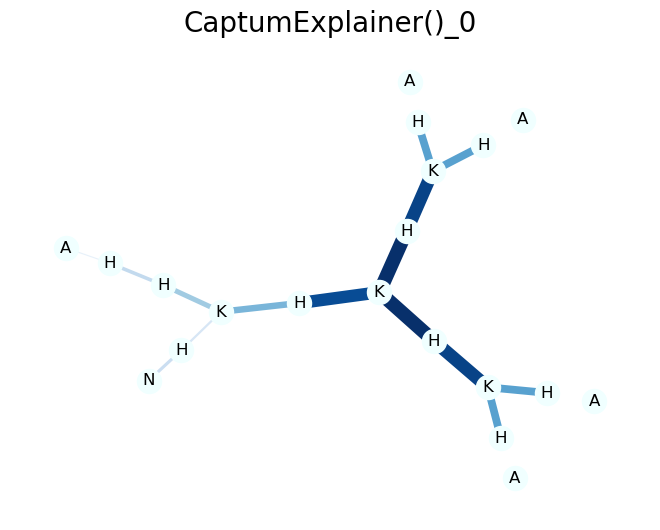

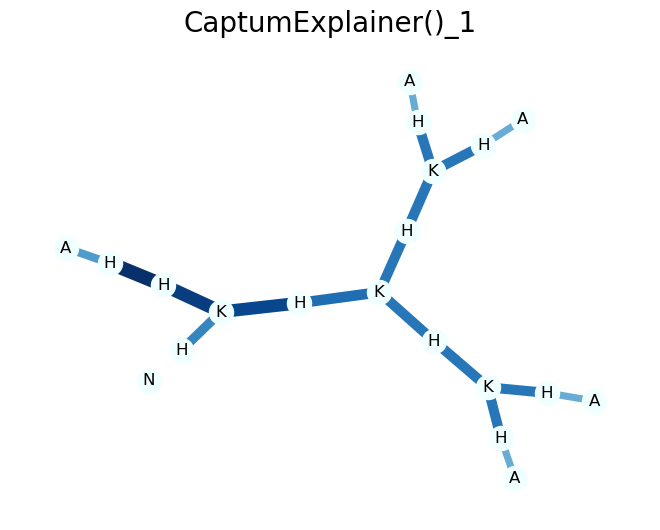

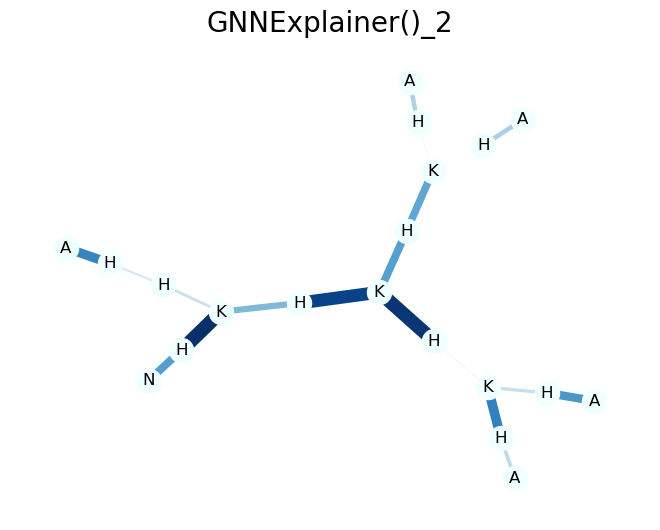

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

algo_test = [CaptumExplainer(attribution_method='Saliency'),CaptumExplainer(attribution_method='IntegratedGradients'),
             GNNExplainer()]

for num, algo in enumerate(algo_test):
    explainer = Explainer(model=model, 
                      algorithm=algo,
                      explanation_type='model',
                      model_config=dict(mode='regression',task_level='graph'),
                      node_mask_type=None,
                      edge_mask_type='object'
                      )
    
    explanation = explainer(x=dataset[0].x, edge_index=dataset[0].edge_index, target=None, batch=torch.zeros(dataset[0].x.shape[0], dtype=int).to(device))

    edgemask = aggregate_edge_directions(explanation.edge_mask.detach().numpy(), dataset[0])
    graph_funcs.plt_vis(atoms, edges, edge_mask=edgemask, title=f'{algo}_{num}', savefig=True)
    




